# Notebook 04 — Modelado Predictivo: Regresión Logística

## FitLife Analytics

Este notebook construye un modelo de Regresión Logística para estimar la probabilidad de abandono (`Churn`) de cada socio, y lo interpreta a través de sus coeficientes.

**Continuidad del proyecto:** el Notebook 03 identificó el perfil de socio de mayor riesgo (nuevo, contrato mensual, joven, sin clases grupales, sin pareja socia, captado por un canal distinto a la recomendación). Este notebook traduce esas observaciones descriptivas en un modelo capaz de estimar, para cualquier socio, una probabilidad concreta de abandono.

**Alcance:** según el Integrador del profesor, basta con seleccionar **una** técnica analítica, valorando la interpretación de resultados por encima de la complejidad del modelo. Por eso se utiliza únicamente Regresión Logística, descartando Random Forest, XGBoost y SHAP planteados en una versión anterior del `business_case.md`.

---
## 1. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted')
print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [2]:
df = pd.read_csv('../data/processed/gym_churn_enriquecido.csv')
print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
df.head(3)

Filas: 4000 | Columnas: 17


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Month_to_end_contract,Lifetime,Churn,genero_texto,grupo_edad,tipo_contrato,nivel_compromiso,perfil_captacion,segmento_lifetime
0,1,1,1,1,0,6,1,29,5.0,3,0,Hombre,26-30,semestral,medio,referido_sin_contacto,nuevo
1,0,1,0,0,1,12,1,31,12.0,7,0,Mujer,31-35,anual,alto,organico_contactado,intermedio
2,0,1,1,0,1,1,0,28,1.0,2,0,Mujer,26-30,mensual,bajo,organico_contactado,nuevo


---
## 2. Selección de variables

### Por qué se excluyen `Lifetime`, `Month_to_end_contract` y `segmento_lifetime`

Estas tres variables presentan **fuga de información (data leakage)**: no describen al socio *antes* de que decidiera irse, sino que son casi una consecuencia directa de que ya se ha ido. La antigüedad media de los socios que se dan de baja es de apenas **1 mes**, y los meses que les quedaban de contrato en el momento de la baja también rondan 1. Incluirlas haría que el modelo pareciera mucho mejor (ROC AUC cercano a 1) sin aportar ningún valor predictivo real: estaría aprendiendo casi la definición de la propia variable objetivo, no un patrón de negocio útil.

Se utilizan en su lugar las variables numéricas originales del dataset, que sí representan información disponible **antes** de que el socio decida abandonar.

In [3]:
VARIABLES = [
    'gender', 'Near_Location', 'Partner', 'Promo_friends',
    'Phone', 'Contract_period', 'Group_visits', 'Age'
]
TARGET = 'Churn'

X = df[VARIABLES]
y = df[TARGET]

print(f'Variables predictoras: {len(VARIABLES)}')
print(f'Distribución de la variable objetivo:')
print(y.value_counts(normalize=True).round(3))

Variables predictoras: 8
Distribución de la variable objetivo:
Churn
0    0.735
1    0.265
Name: proportion, dtype: float64


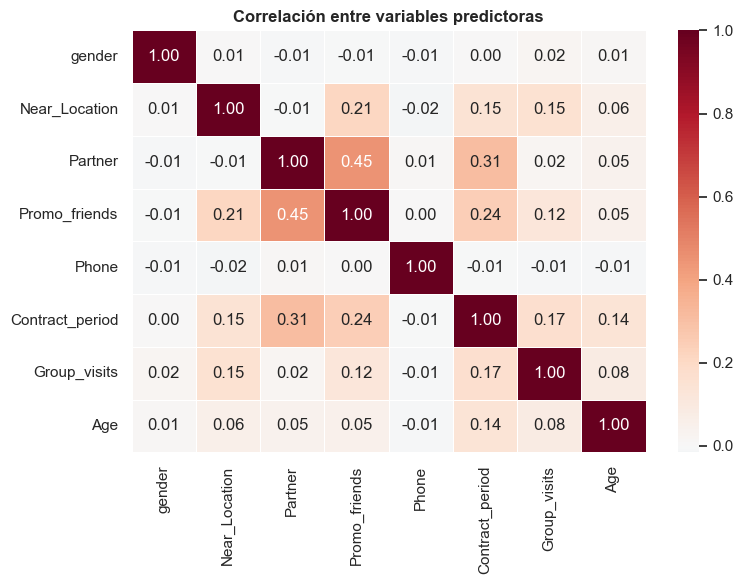

In [4]:
# Comprobación de multicolinealidad entre las variables predictoras

plt.figure(figsize=(8, 6))

sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)

plt.title('Correlación entre variables predictoras', fontweight='bold')

plt.tight_layout()

plt.savefig('../docs/img/18_correlacion_predictoras.png', bbox_inches='tight')

plt.show()

**Sin multicolinealidad relevante**: todas las correlaciones entre variables predictoras están por debajo de 0.21. Cada variable aporta información distinta al modelo.

---
## 3. División en entrenamiento y prueba

Se separa el 80% de los socios para entrenar el modelo y el 20% restante para evaluarlo con datos que el modelo no ha visto. Se usa `stratify=y` para que la proporción de bajas (26.5%) se mantenga igual en ambos conjuntos.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} socios')
print(f'Prueba:        {X_test.shape[0]} socios')
print()
print(f'Proporción de churn en entrenamiento: {y_train.mean():.3f}')
print(f'Proporción de churn en prueba:        {y_test.mean():.3f}')

Entrenamiento: 3200 socios
Prueba:        800 socios

Proporción de churn en entrenamiento: 0.265
Proporción de churn en prueba:        0.265


---
## 4. Escalado de variables

La Regresión Logística calcula sus coeficientes a partir de la escala de cada variable. `Age` va de 18 a 41 y `Contract_period` de 1 a 12, mientras que el resto son binarias (0/1). Sin escalar, los coeficientes no serían comparables entre sí y la interpretación de "qué variable importa más" quedaría distorsionada.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Variables escaladas (media 0, desviación típica 1)')

Variables escaladas (media 0, desviación típica 1)


---
## 5. Entrenamiento del modelo

In [7]:
modelo = LogisticRegression(random_state=42, max_iter=1000)
modelo.fit(X_train_scaled, y_train)

print('Modelo entrenado correctamente')

Modelo entrenado correctamente


---
## 6. Evaluación del modelo

In [8]:
y_pred = modelo.predict(X_test_scaled)
y_proba = modelo.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Activo', 'Baja']))
print(f'ROC AUC: {roc_auc_score(y_test, y_proba):.3f}')

              precision    recall  f1-score   support

      Activo       0.83      0.93      0.87       588
        Baja       0.70      0.47      0.56       212

    accuracy                           0.81       800
   macro avg       0.76      0.70      0.72       800
weighted avg       0.79      0.81      0.79       800

ROC AUC: 0.871


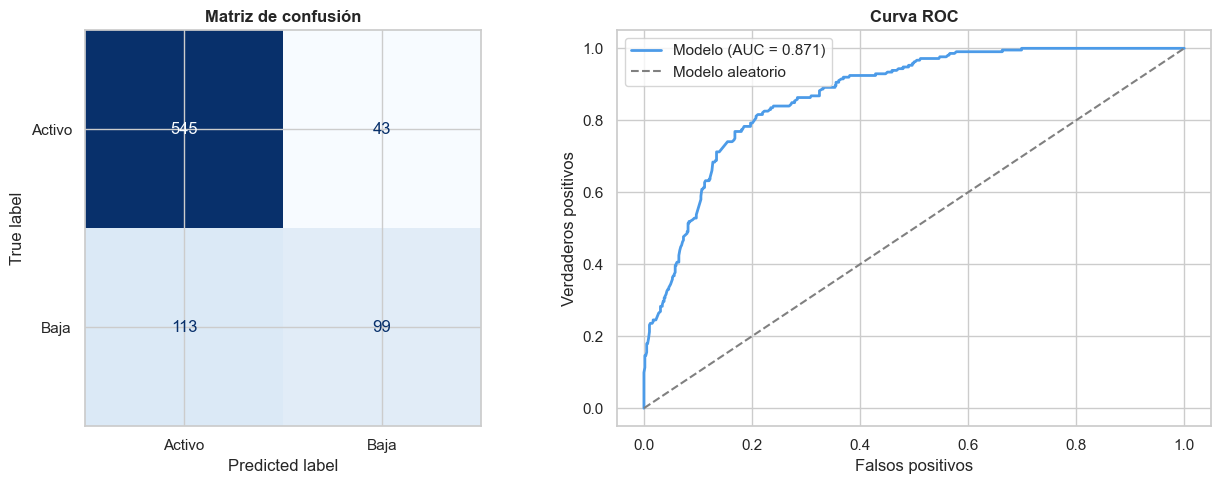

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))



# Matriz de confusión

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=['Activo', 'Baja'])

disp.plot(ax=axes[0], cmap='Blues', colorbar=False)

axes[0].set_title('Matriz de confusión', fontweight='bold')



# Curva ROC

fpr, tpr, _ = roc_curve(y_test, y_proba)

auc = roc_auc_score(y_test, y_proba)

axes[1].plot(fpr, tpr, color='#4C9BE8', linewidth=2, label=f'Modelo (AUC = {auc:.3f})')

axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Modelo aleatorio')

axes[1].set_xlabel('Falsos positivos')

axes[1].set_ylabel('Verdaderos positivos')

axes[1].set_title('Curva ROC', fontweight='bold')

axes[1].legend()



plt.tight_layout()

plt.savefig('../docs/img/19_evaluacion_modelo.png', bbox_inches='tight')

plt.show()

**Lectura de las métricas:**
- **ROC AUC ≈ 0.87**: el modelo distingue bien entre socios que se quedan y socios que se van, muy por encima del azar (0.5).
- **Recall en "Baja" ≈ 0.47**: de cada 100 socios que realmente abandonan, el modelo detecta a unos 47 de antemano. Es un punto de partida útil para un sistema de alertas, aunque no detecta a todos.
- **Precisión en "Baja" ≈ 0.70**: de cada 100 socios que el modelo señala como riesgo, 70 efectivamente se dan de baja — las alertas son razonablemente fiables, no ruido.

---
## 7. Interpretación: coeficientes y odds ratios

Esta es la parte que el Integrador del profesor valora especialmente: no basta con que el modelo funcione, hay que entender **por qué**.

El **odds ratio** (exponencial del coeficiente) indica cuánto se multiplican las probabilidades de abandono por cada aumento de una desviación típica en la variable:
- Un odds ratio **mayor que 1** aumenta el riesgo de abandono.
- Un odds ratio **menor que 1** lo reduce.
- Cuanto más se aleje de 1 (en cualquier dirección), mayor es su efecto.

In [10]:
coeficientes = pd.DataFrame({
    'variable': VARIABLES,
    'coeficiente': modelo.coef_[0],
    'odds_ratio': np.exp(modelo.coef_[0])
}).sort_values('coeficiente')

coeficientes

,variable,coeficiente,odds_ratio
5,Contract_period,-1.374852,0.252877
7,Age,-1.153788,0.315440
6,Group_visits,-0.288793,0.749167
3,Promo_friends,-0.143761,0.866095
1,Near_Location,-0.116835,0.889732
4,Phone,-0.046518,0.954547
2,Partner,-0.043932,0.957019
0,gender,0.006625,1.006647


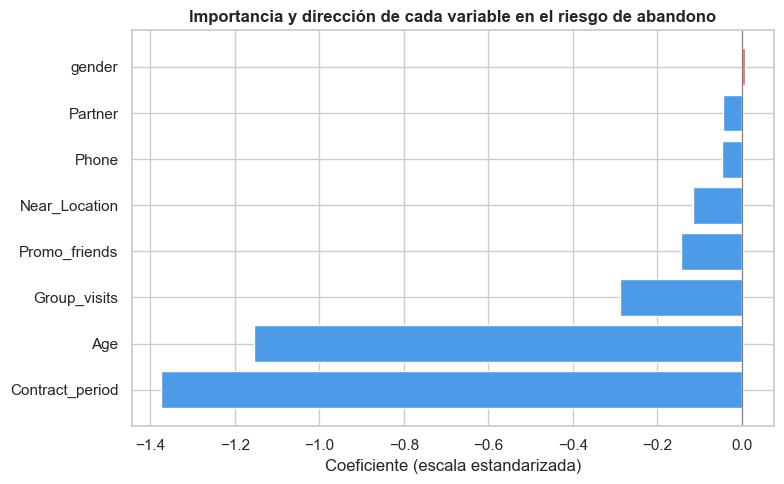

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

colores = ['#4C9BE8' if c < 0 else '#E85C5C' for c in coeficientes['coeficiente']]

ax.barh(coeficientes['variable'], coeficientes['coeficiente'], color=colores)

ax.axvline(0, color='gray', linewidth=0.8)

ax.set_xlabel('Coeficiente (escala estandarizada)')

ax.set_title('Importancia y dirección de cada variable en el riesgo de abandono', fontweight='bold')

plt.tight_layout()

plt.savefig('../docs/img/20_coeficientes_modelo.png', bbox_inches='tight')

plt.show()

**Conclusión de la interpretación:**

- **`Contract_period` y `Age` son, con diferencia, las variables más influyentes.** Ambas reducen el riesgo de abandono: a mayor duración de contrato y a mayor edad, menor probabilidad de baja. Esto confirma cuantitativamente las Hipótesis H1 y el hallazgo de edad del Notebook 03.
- **`Group_visits` y `Promo_friends`** también reducen el riesgo, de forma más moderada — coherente con las Hipótesis H4 y H3.
- **`Partner`** reduce el riesgo en menor medida de lo que sugería el análisis univariante del Notebook 03 (H5): parte de su efecto aparente podría solaparse con el de otras variables como `Age` o `Group_visits` una vez se consideran todas juntas.
- **`gender` y `Phone` apenas tienen efecto** (coeficientes cercanos a cero): el género del socio y si tiene teléfono registrado no son factores relevantes de abandono.

---
## 8. Conclusiones del Notebook 04

### Rendimiento del modelo
- ROC AUC de 0.87 en datos de prueba: capacidad discriminativa buena, sin fuga de información.
- El modelo detecta correctamente a cerca de la mitad de los socios que realmente abandonan (Recall 0.47), con una fiabilidad razonable en sus alertas (Precisión 0.70).

### Variables más relevantes
`Contract_period` y `Age` dominan claramente la predicción, seguidas de `Group_visits` y `Promo_friends`. Esto es coherente de principio a fin con los hallazgos del Notebook 03: el contrato, la edad, las clases grupales y el canal de captación no solo se relacionan con el abandono de forma aislada — siguen siendo predictores sólidos incluso cuando se combinan todos a la vez.

### Limitación reconocida
El modelo no incorpora antigüedad ni tiempo restante de contrato por el riesgo de fuga de información explicado en la Sección 2. Esto probablemente limita su techo de rendimiento: un modelo con esas variables llegaría a un AUC más alto, pero no sería utilizable en la práctica para anticipar bajas futuras.

### Próximos pasos
Las probabilidades de abandono (`y_proba`) calculadas por este modelo alimentarán la segmentación de riesgo de la vista operacional del Dashboard de Power BI (Fase 7).